# Data-driven Model Learning

In [22]:
import gym
import matplotlib.pyplot as plt
import numpy as np
import scipy.linalg as sla

## Environment: Inverted Pendulum
We'll use the aigym version of the the inverted pendulum, and implement the following changes:
- Start state distribution 
$$
P(x_0) = Uniform \left(\left[ \begin{matrix}-\pi \\-1 \end{matrix} \right],\left[ \begin{matrix}\pi \\1 \end{matrix} \right]
\right)
$$
- 20 Hz sampling frequency

In [23]:
all_envs = gym.envs.registry.all()

robotics_envs = [env_spec.id for env_spec in all_envs if env_spec.id.startswith('gym_robotics:')]

for env_name in robotics_envs:
    print(env_name)

In [26]:
gym.make("FetchReach-v1")

DependencyNotInstalled: No module named 'mujoco_py'. (HINT: you need to install mujoco_py, and also perform the setup instructions here: https://github.com/openai/mujoco-py/.)

In [3]:
env = gym.make("Pendulum-v1")

In [4]:
env.dt # sampling frequency of 20 Hz?

0.05

$dt = \frac{1}{Fs}$

## Linear Regression Model
The maximum likelihood estimator is given by
$$
\boldsymbol\theta^{\text{ML}} = (\boldsymbol X^T\boldsymbol X)^{-1}\boldsymbol X^T\boldsymbol y\in\mathbb{R}^D\,,
$$
where 
$$
\boldsymbol X = [\boldsymbol x_1, \ldots, \boldsymbol x_N]^T\in\mathbb{R}^{N\times D}\,,\quad \boldsymbol y = [y_1, \ldots, y_N]^T \in\mathbb{R}^N\,.
$$

In [5]:
def lr_ml_estimate(X, y):
    # X: N x D matrix of training inputs
    # y: N x 1 vector of training targets/observations
    # returns: maximum likelihood parameters (D x 1)
    
    theta_ml = np.linalg.solve(X.T @ X, X.T @ y)
    return theta_ml

In [6]:
def lr_predict(Xtest, theta):
    # Xtest: K x D matrix of test inputs
    # theta: D x 1 vector of parameters
    # returns: prediction of f(Xtest); K x 1 vector
    
    prediction =  Xtest @ theta
    
    return prediction 

## Successor State Predictions

Get initial trajectory

In [7]:
def unfeaturize(feat_x):
    return np.array([np.arctan2(feat_x[1],feat_x[0]),feat_x[2]])

In [8]:
done = False
x = env.reset()

traj = []
states = [x]
while not done:
    u = env.action_space.sample()
    x_ = unfeaturize(x)
    X_aug = np.hstack((x_,u))
    x,r,done,info = env.step(u)
    
    # preprocess successor state (rect -> polar)
    #y = np.array([np.arctan2(x[1],x[0]),x[2]])
    y = unfeaturize(x)
    states.append(y)
    # predict, just the state (not the angular velocity)
    traj.append(np.hstack((X_aug,y)))    
    # env.render()
env.close()

In [9]:
np.arctan2(x[1],x[0])

-1.7384734

Fit model from initial trajectory

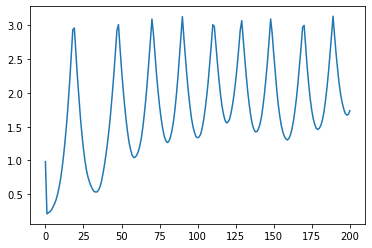

In [10]:
states_np = np.array(states)
plt.plot(states_np[:,0])

In [11]:
D = 4
xy_train = np.array(traj)
lrmle_theta = lr_ml_estimate(xy_train[:,:D], xy_train[:,D:])

In [12]:
xy_train.shape

(200, 7)

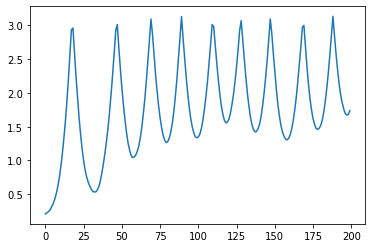

In [13]:
plt.plot(xy_train[:,D:D+1])

Use model for predictions

In [14]:
from sklearn.metrics import mean_squared_error as mse

In [15]:
done = False
x = env.reset()

losses = []
preds = []
truth = []
while not done:
    u = env.action_space.sample()
    x_ = unfeaturize(x)
    X_aug = np.hstack((x_,u))
    x,r,done,info = env.step(u)
    y_pred = lr_predict(X_aug, lrmle_theta)
    preds.append(y_pred)
    y = unfeaturize(x)
    truth.append(y)
    # preprocess successor state (rect -> polar)
    # y = np.array([np.arctan(x[1],x[0]),x[2]])  
    losses.append(mse(x,y_pred))
    #env.render()
env.close()
print(sum(losses))
p = np.array(preds)
t = np.array(truth)

680.5320398807526


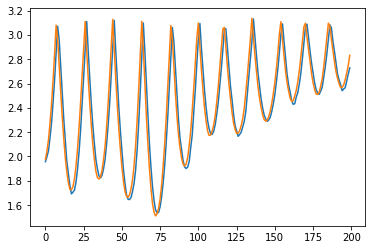

In [16]:
plt.plot(p[:,0])
plt.plot(t[:,0])
plt.show()

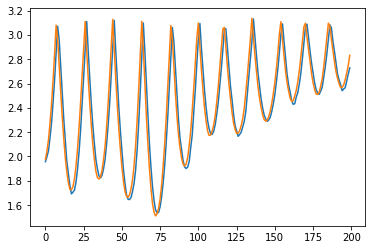

In [17]:
plt.plot(p[:,0])
plt.plot(t[:,0])
plt.show()

In [36]:
x.shape

(3,)